# Perceptron from scratch in numpy

These code and images are from Chapter 2 and 3 in Raschka. (To retain the images do not execute the image code blocks!)

<br>
<br>

## The formal definition of an artificial neuron

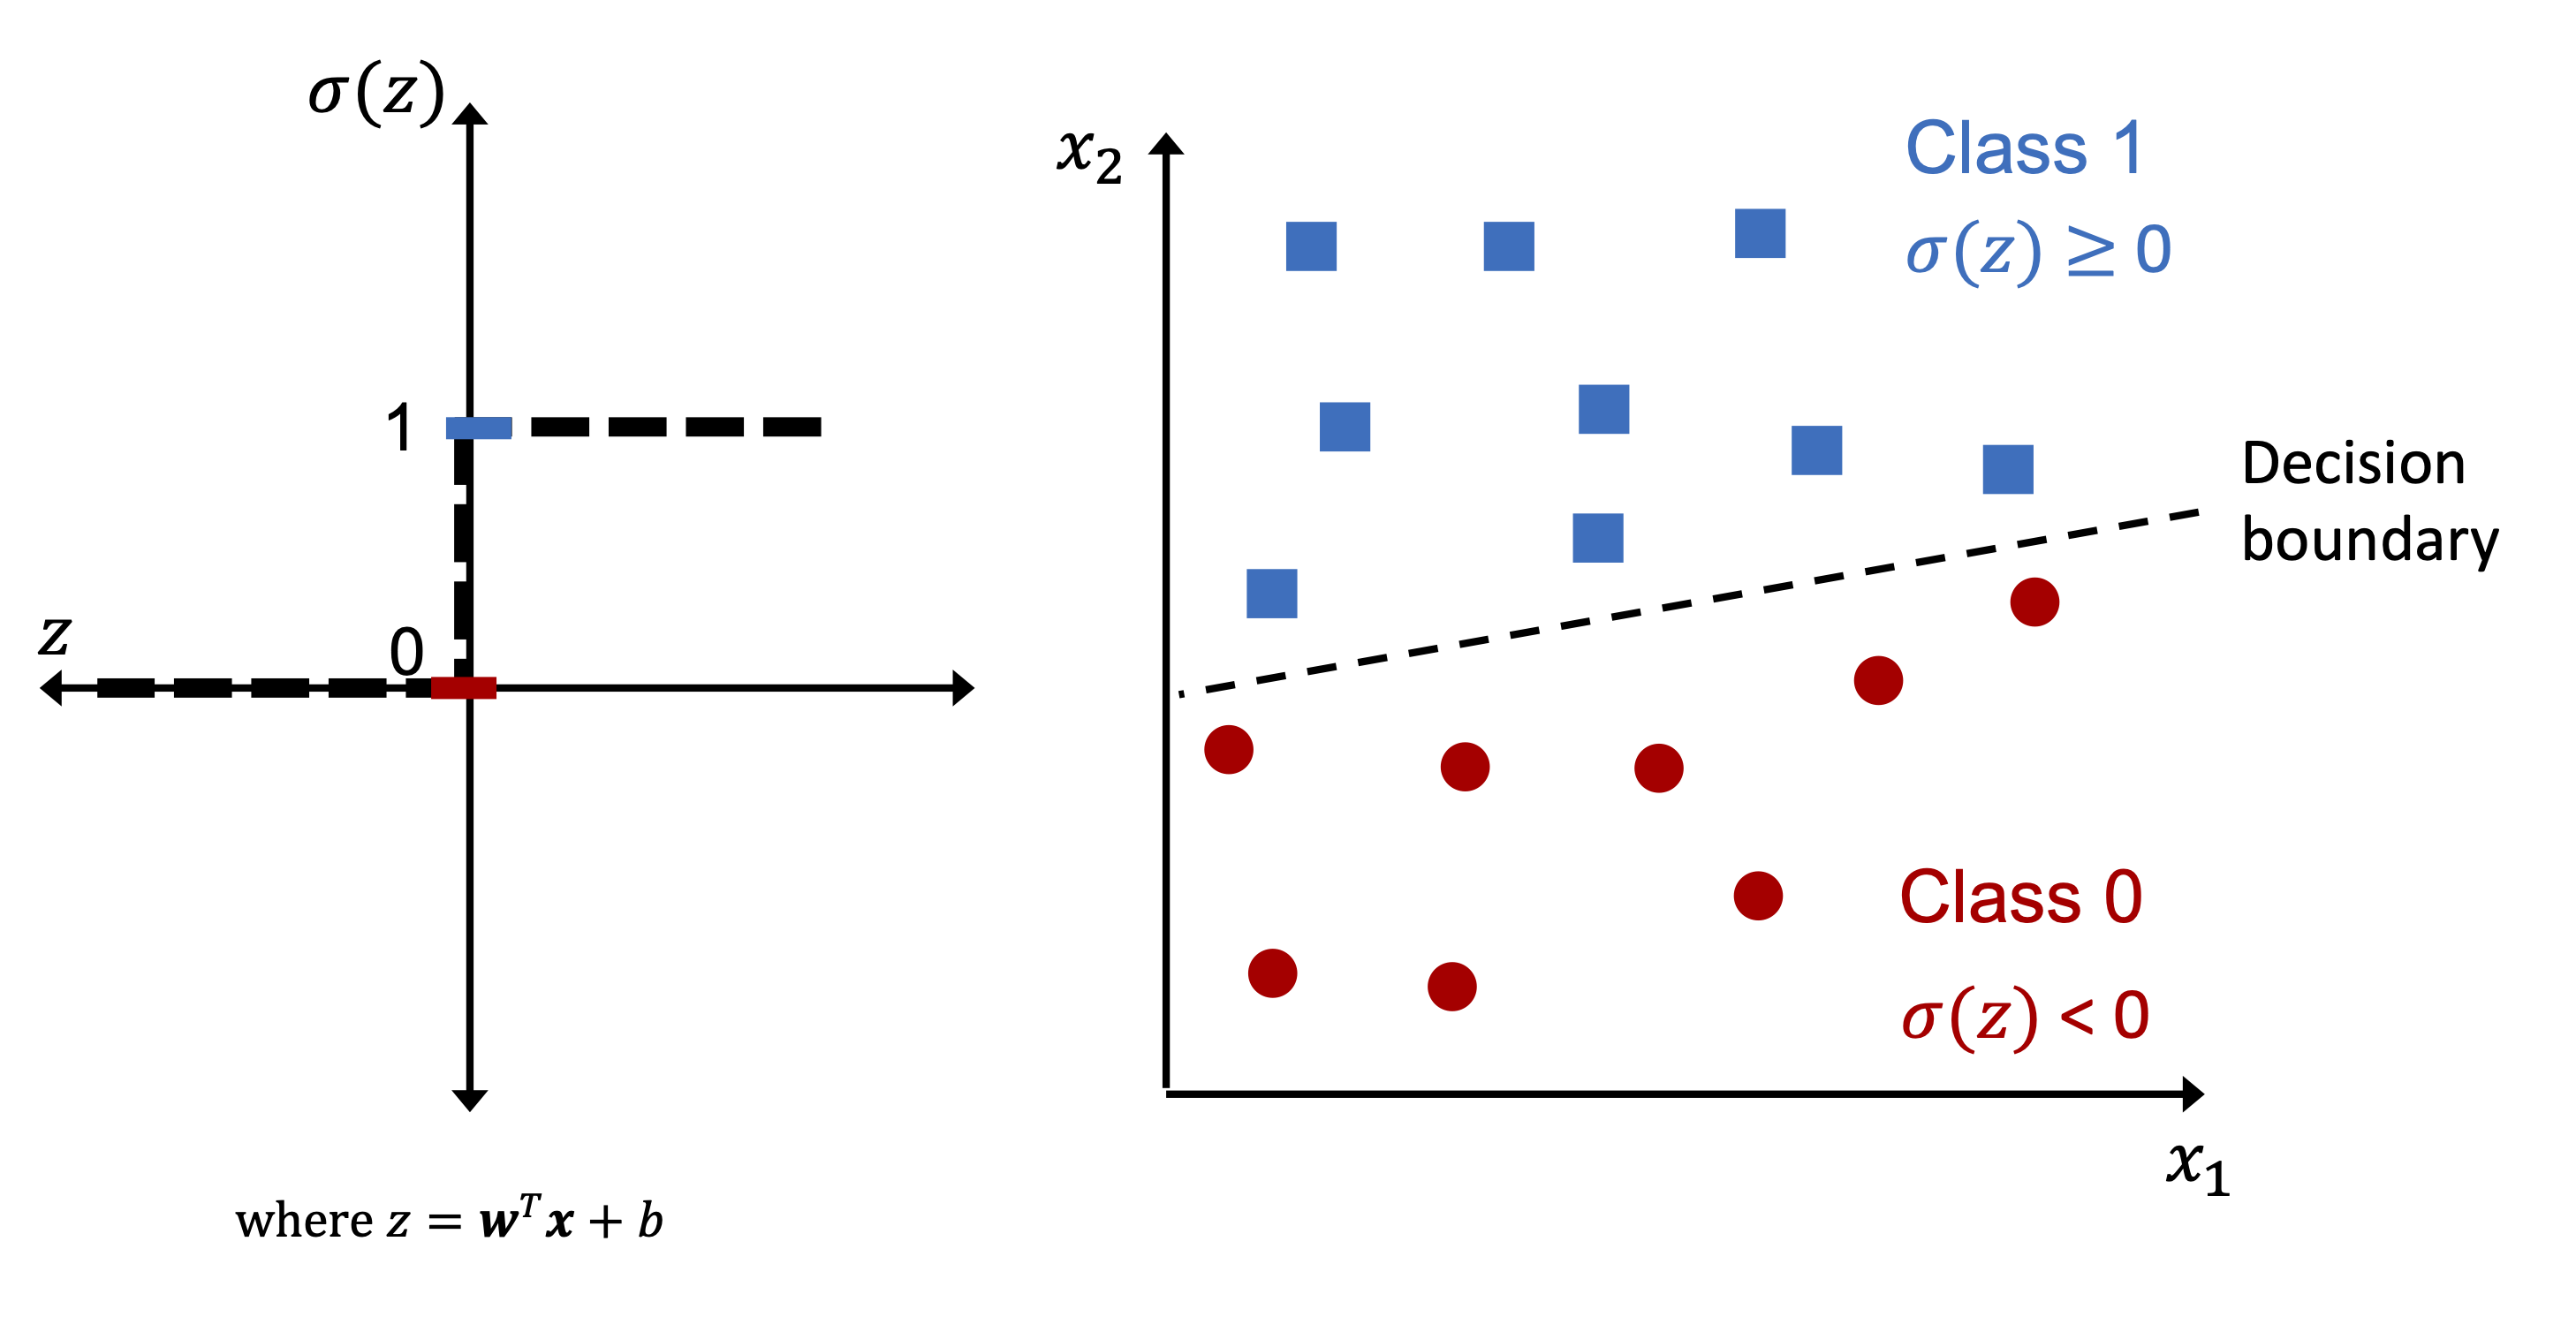

In [5]:
#Image(filename='./figures/02_02.png', width=500) 

## The perceptron learning rule

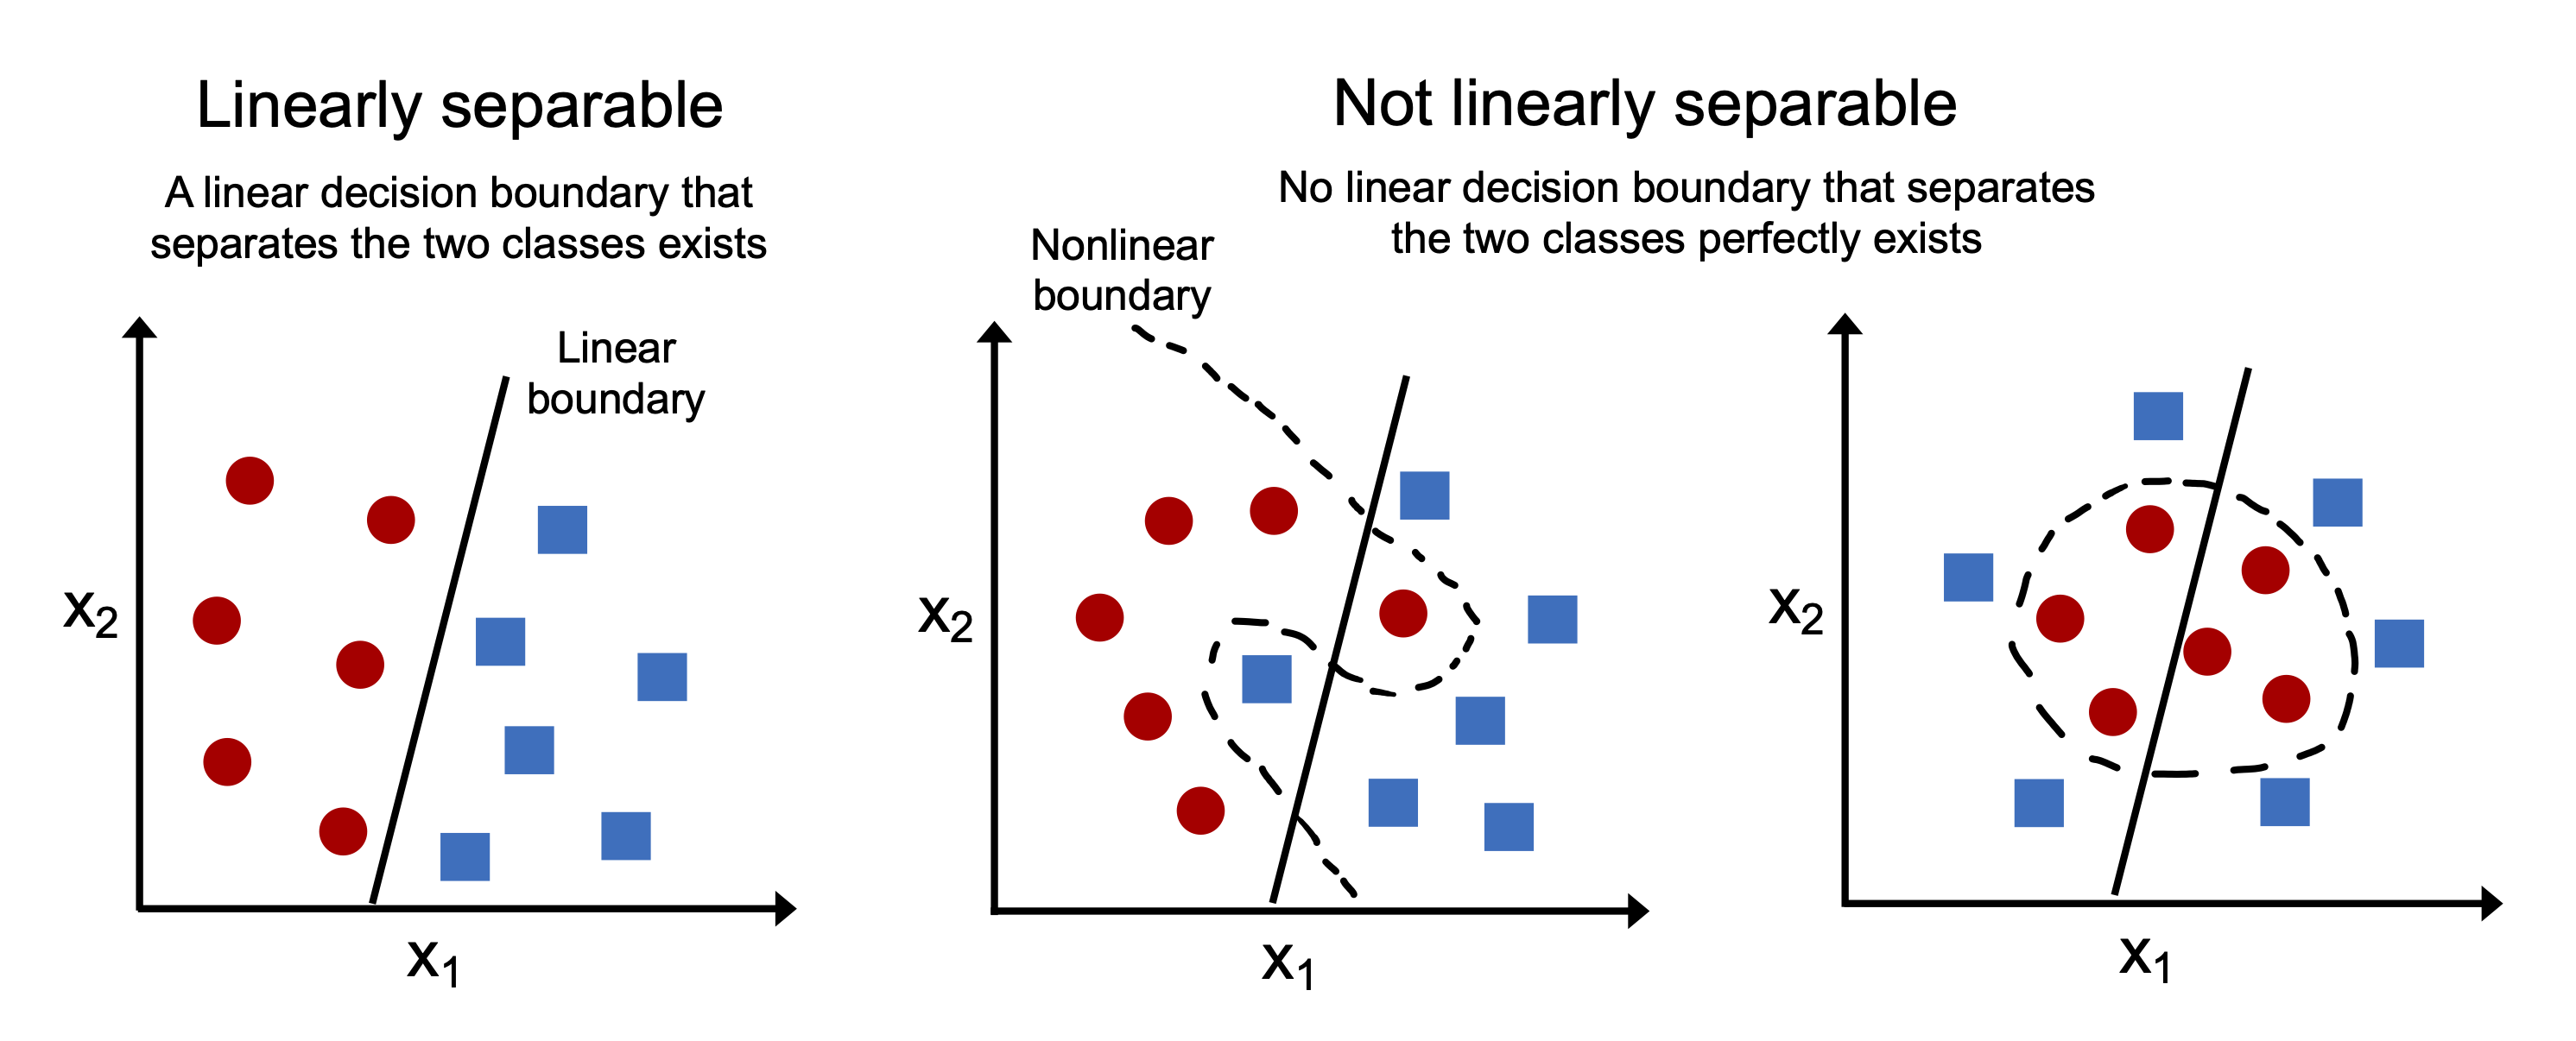

In [6]:
#Image(filename='./figures/02_03.png', width=600) 

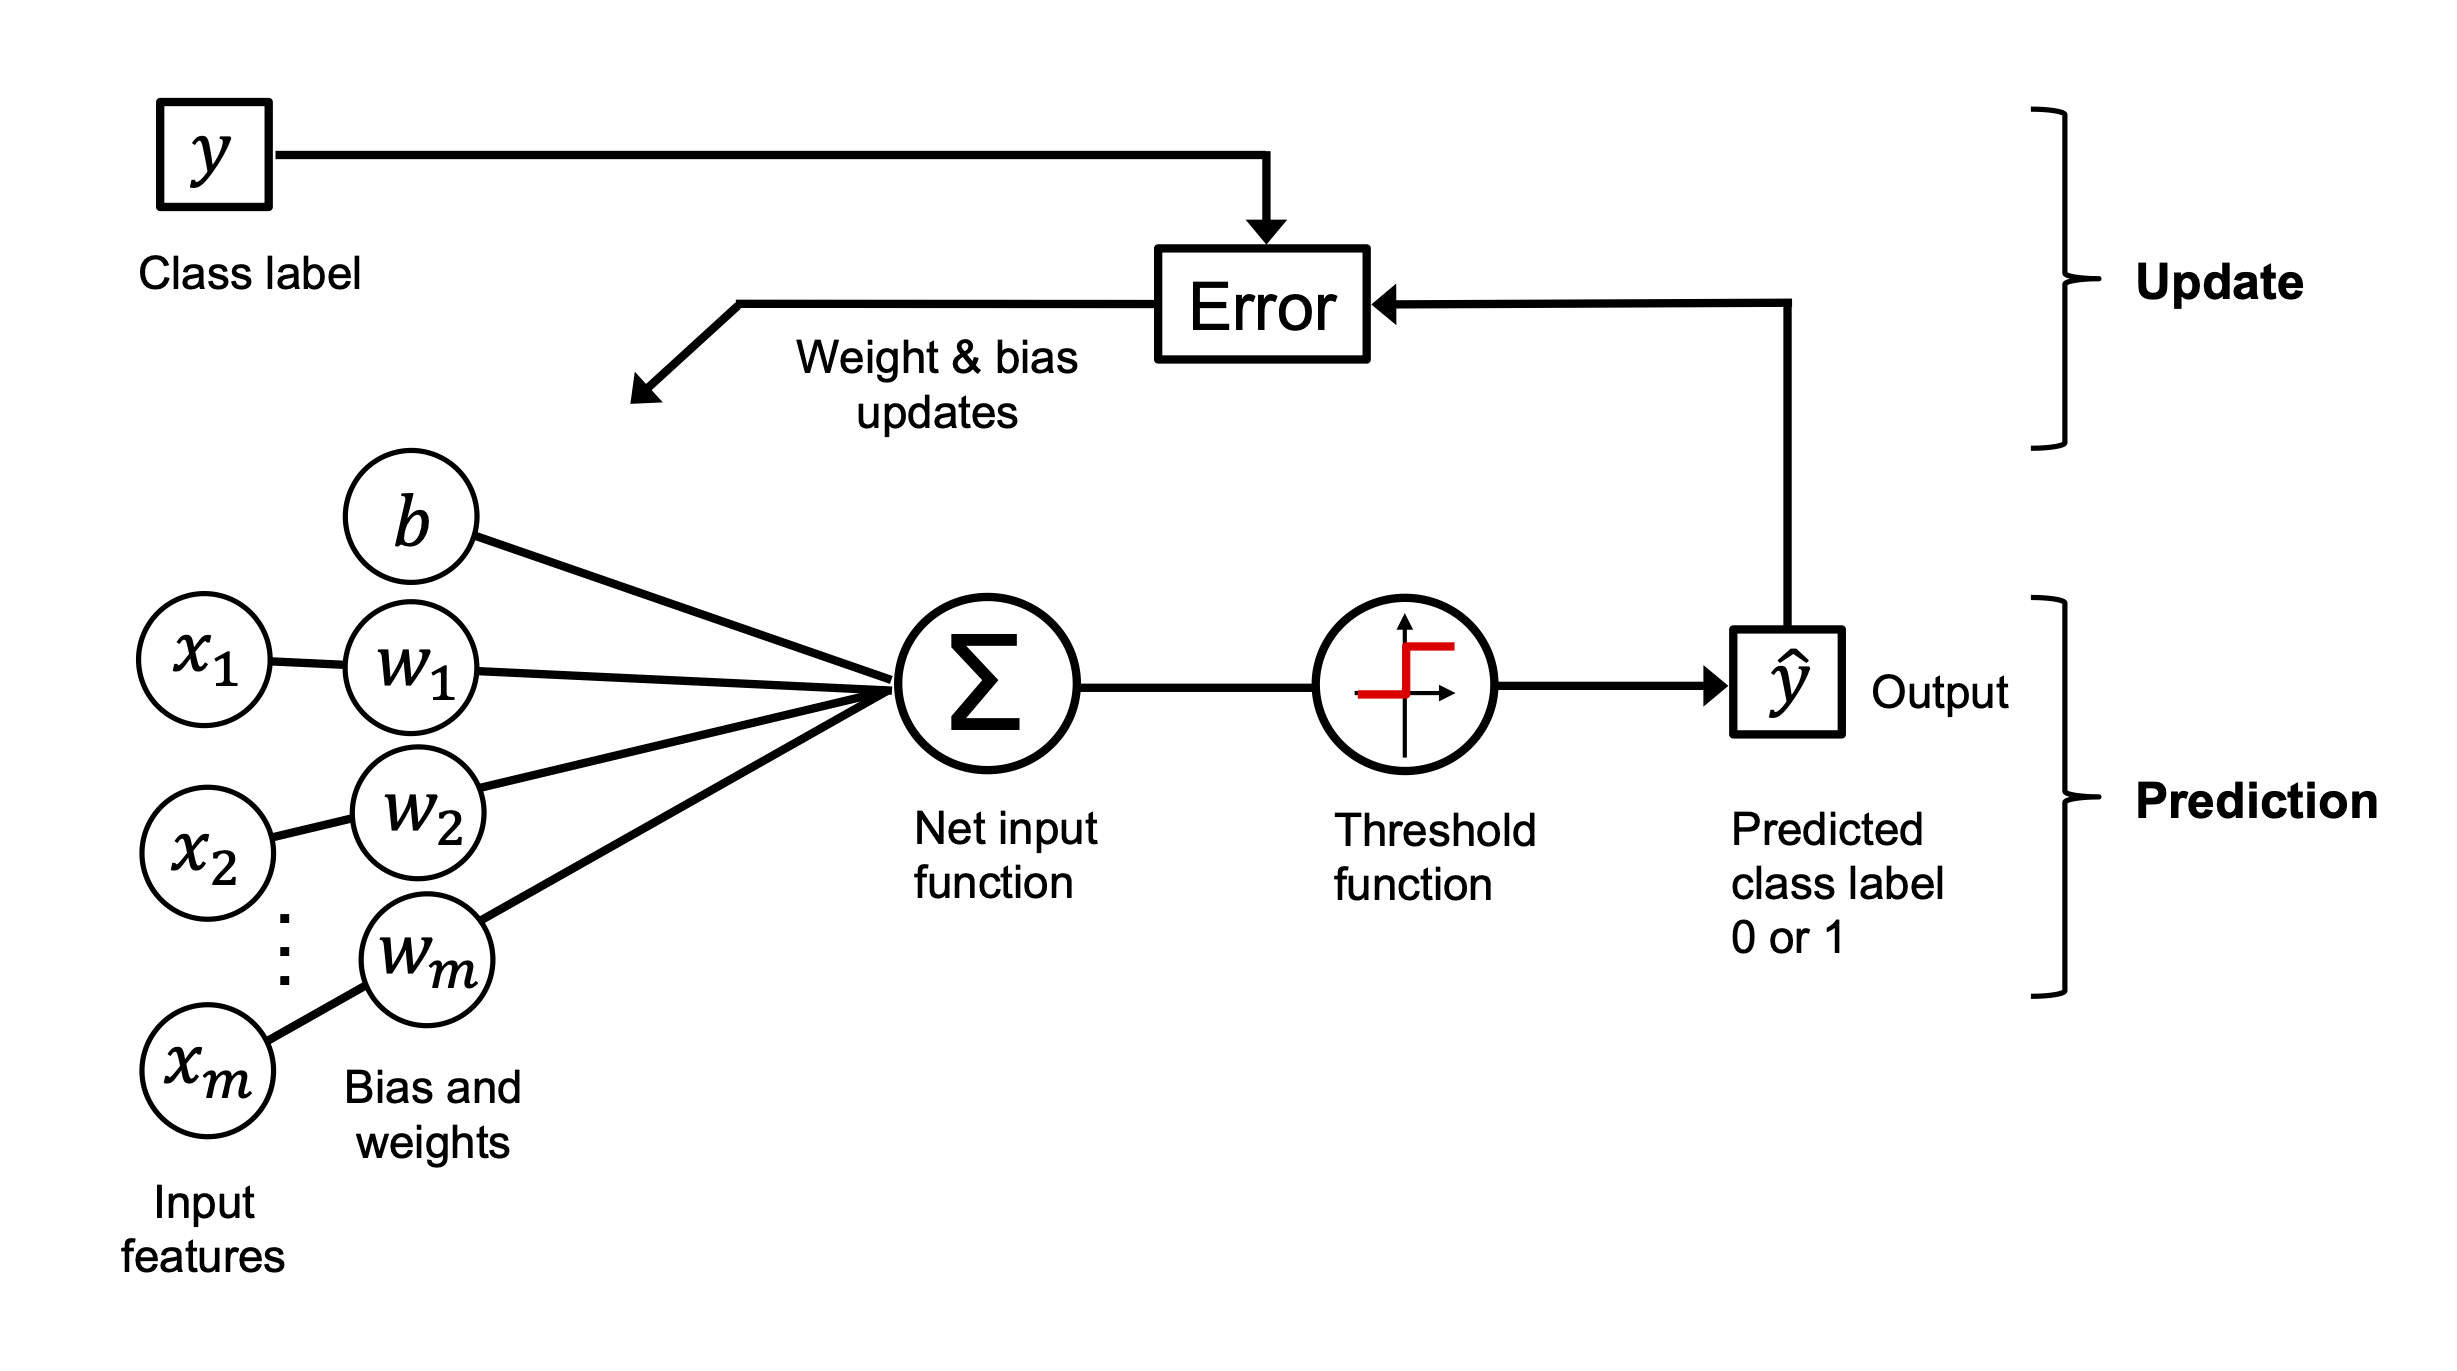

In [7]:
 #Image(filename='./figures/02_04.png', width=600) 

<br>
<br>

# Object-oriented APIs

The goals are 

-  Understand and apply Python code for these class definitions.
-  How perceptrons and adaline work; connect the code with the mathematics
-  How loss and gradient descent work in the context of ml models.
-  Fit these simple models to familiar data sets and experiment
-  Later, we will adapt perceptron to obtain linear and logistic regression with gradient descent

## Perceptron classifier

For a perceptron, the "loss function" is simply the error, though it is typically not referred to as that. The perceptron takes the samples one at a time and adjusts the weights and bias each time. It goes through all the samples and then repeats for however many epochs you specify.

In [ ]:
import numpy as np


class Perceptron:
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)
        
        self.errors_ = []

        for _ in range(self.n_iter):     ## loop over epochs
            errors = 0
            for xi, target in zip(X, y):    ## loop over each sample, adjusting weights and bias
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)  ## if the update is zero, the sample is correctly classified; counts how many are not
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_   

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)

The following plot assumes you have fit a model called `ppn` on some data. Try it! **Note:** If your data is stored as a data frame you may need to extract the data matrix values as an array using `.values` attribute,

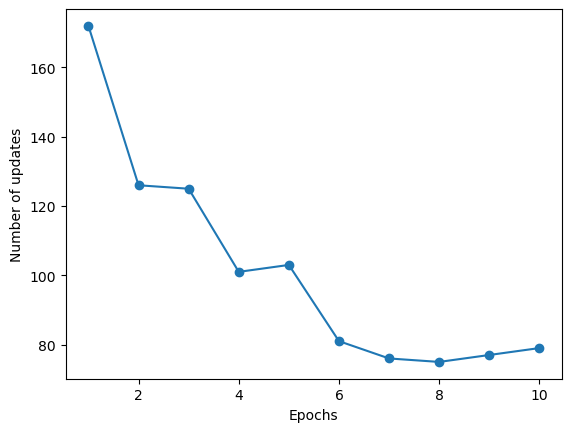

In [10]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')

# plt.savefig('images/02_07.png', dpi=300)
plt.show()

## Adaptive linear neurons

Adaline replaces the error from the perceptron with mean square error.

## Minimizing loss functions with gradient descent

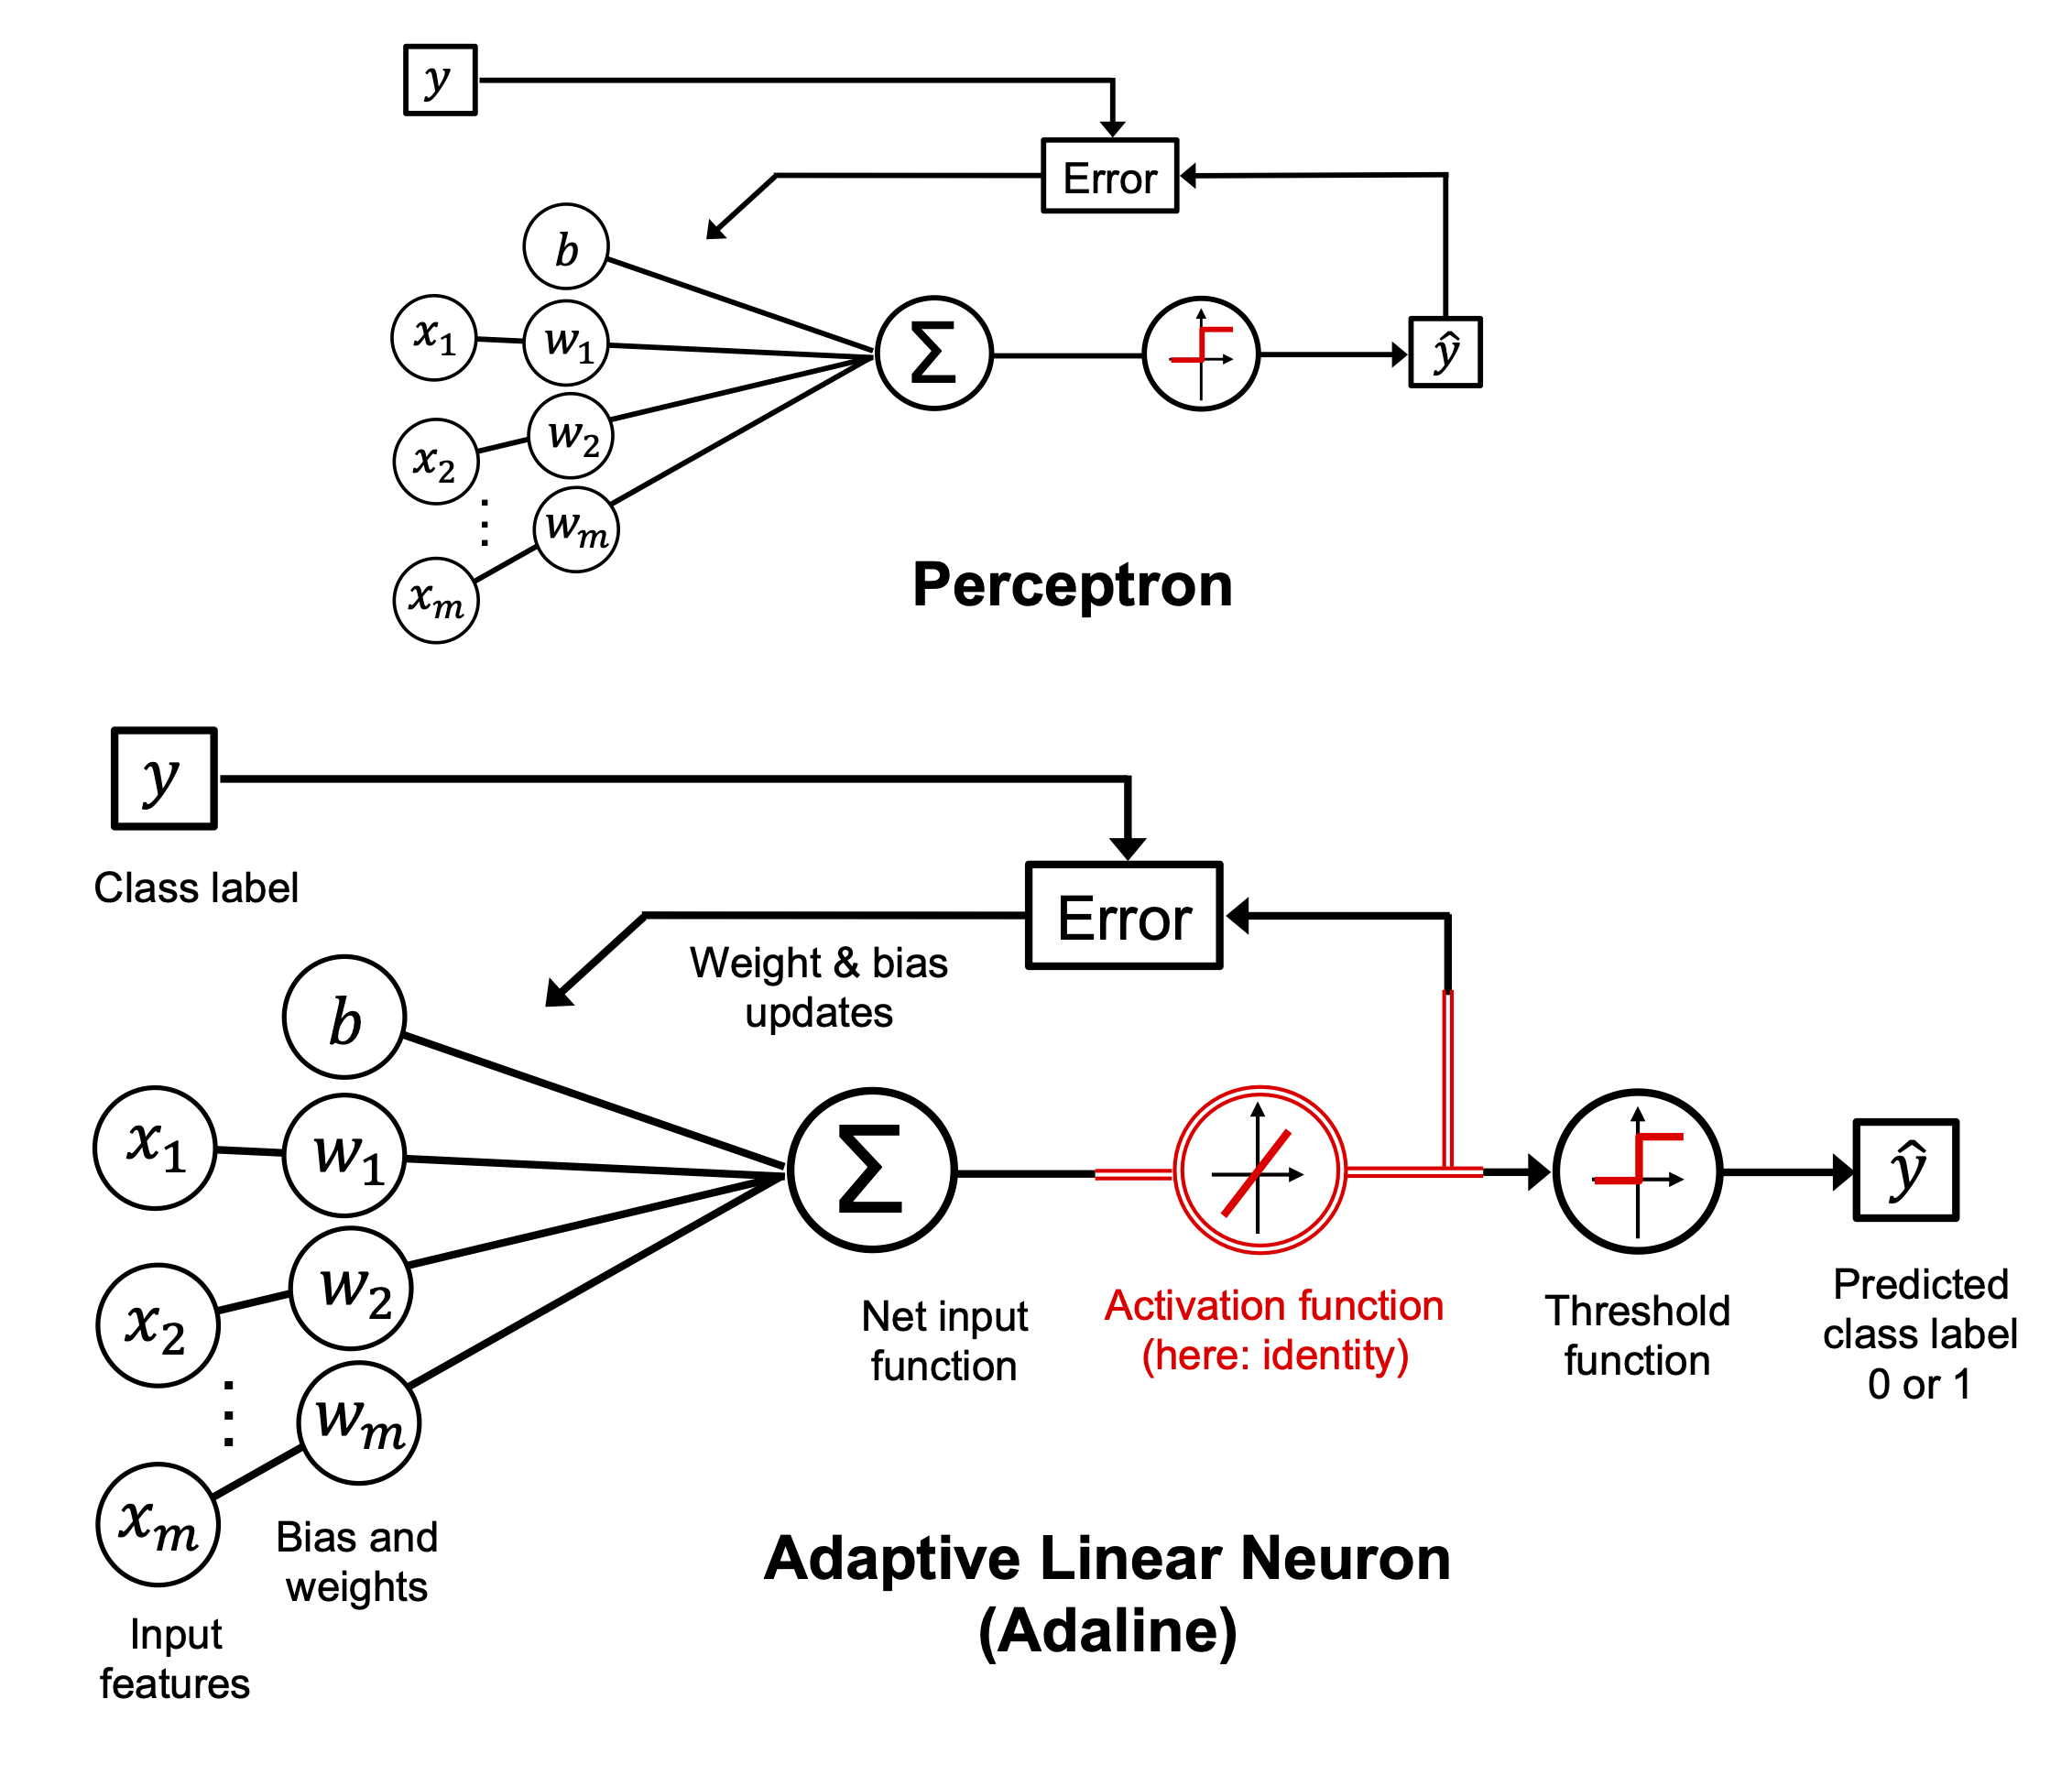

In [15]:
 Image(filename='./figures/02_09.png', width=600) 

To fit the Adaline model, we will use gradient descent, which is a very broad class of optimization schemes used widely in machine learning, deep learning, and elsewhere. But first will need some calculus! 

Exercise:
Try your Adaline classifier on some binary classification data (for example the penguins data with species == Gentoo).
Plot the loss vs epoch
Find the accuracy

<br>
<br>